#### Nigeria Climate Data Analysis

##### Importing libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Loading data, adding country, creating date and month columns

In [4]:
df = pd.read_csv("../data/Nigeria.csv")
df["Country"] = "Nigeria"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month


df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


Handling missing values and duplicates

In [5]:
df.replace(-999, np.nan, inplace=True)

duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate rows")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed")
else:
    print("No duplicates to remove")


print("\nChecking for missing values...")
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100


has_missing = missing_count[missing_count > 0]
if len(has_missing) > 0:
    print("\nColumns with missing values:")
    for col in has_missing.index:
        print(f"  {col}: {has_missing[col]} missing ({missing_percent[col]:.1f}%)")
else:
    print("No missing values found in any column")


high_missing = missing_percent[missing_percent > 5]
if len(high_missing) > 0:
    print("\nColumns with more than 5% missing:")
    for col in high_missing.index:
        print(f"  {col}: {high_missing[col]:.1f}%")
else:
    print("\nNo columns have more than 5% missing values")


print("\nSummary statistics:")
df.describe()

Found 0 duplicate rows
No duplicates to remove

Checking for missing values...
No missing values found in any column

No columns have more than 5% missing values

Summary statistics:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


The average temperature in Nigeria is 26.7°C. Temperatures range from 21.1°C to 29.3°C. Average daily rainfall is 4.2 mm. The heaviest rain day had 166.1 mm. Average humidity is 85.2%. The data covers January 2015 to March 2026.

##### Checking for outliers using Z-scores(Z-score above 3 means the value is far from average)

In [6]:
# Columns to check
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df[outlier_cols]))

# Count outliers per column
outlier_count = (z_scores > 3).sum(axis=0)

print("Outliers found per column:")
for col, count in zip(outlier_cols, outlier_count):
    print(f"  {col}: {count} outliers")

# Total outliers
total_outliers = outlier_count.sum()
print(f"\nTotal outliers across all columns: {total_outliers}")

# Export cleaned data
df.to_csv("../data/Nigeria_clean.csv", index=False)
print("\nCleaned data saved to data/Nigeria_clean.csv")

Outliers found per column:
  T2M: 10 outliers
  T2M_MAX: 1 outliers
  T2M_MIN: 68 outliers
  PRECTOTCORR: 75 outliers
  RH2M: 128 outliers
  WS2M: 5 outliers
  WS2M_MAX: 10 outliers

Total outliers across all columns: 297

Cleaned data saved to data/Nigeria_clean.csv


I found 297 outliers. Most of them are in humidity (128 outliers), rainfall (75 outliers), and night temperature (68 outliers). Rainfall and humidity have many extremes because Nigeria has a tropical climate with wet and dry seasons. I decided to keep all outliers. Extreme weather really happens. Removing them would make the data less realistic.

##### Plotting monthly average temperature (T2M) line chart

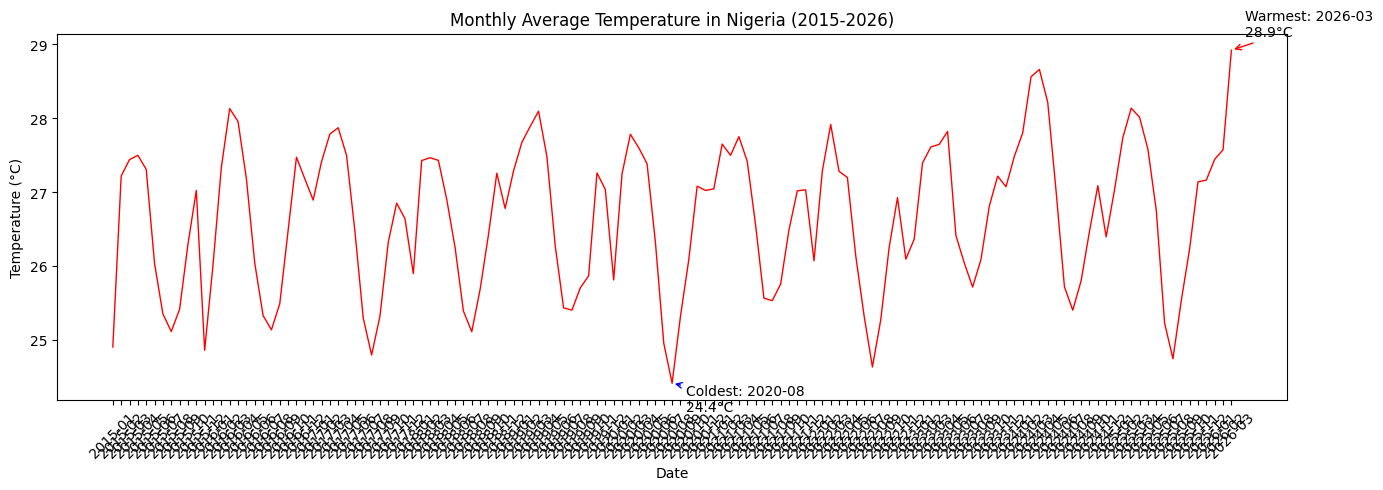

In [7]:
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp.index.astype(str), monthly_temp.values, color='red', linewidth=1)

# Find warmest and coldest months
warmest = monthly_temp.idxmax()
coldest = monthly_temp.idxmin()
warmest_val = monthly_temp.max()
coldest_val = monthly_temp.min()

plt.annotate(f'Warmest: {warmest}\n{warmest_val:.1f}°C', 
             xy=(list(monthly_temp.index).index(warmest), warmest_val),
             xytext=(10, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.annotate(f'Coldest: {coldest}\n{coldest_val:.1f}°C',
             xy=(list(monthly_temp.index).index(coldest), coldest_val),
             xytext=(10, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue'))

plt.title('Monthly Average Temperature in Nigeria (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Plotting monthly total rainfall(PRECTOTCORR) bar chart

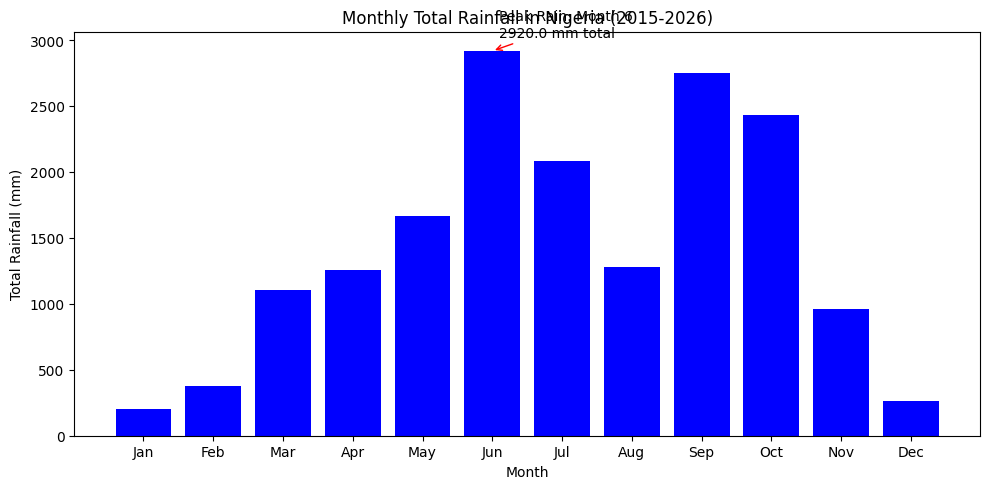

In [8]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum()

plt.figure(figsize=(10, 5))
plt.bar(monthly_rain.index, monthly_rain.values, color='blue')

# Find peak rainy month
peak_month = monthly_rain.idxmax()
peak_val = monthly_rain.max()

plt.annotate(f'Peak Rain: Month {peak_month}\n{peak_val:.1f} mm total',
             xy=(peak_month, peak_val),
             xytext=(5, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Monthly Total Rainfall in Nigeria (2015-2026)')
plt.xlabel('Month')
plt.ylabel('Total Rainfall (mm)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

The warmest month was March 2026 at 28.9°C. The coldest month was August 2020 at 24.4°C.
June has the most rain with 2920.0 mm total. Rainfall is highest in June. The driest months appear to be January.

##### Creating correlation heatmap to see how weather variables relate to each other.

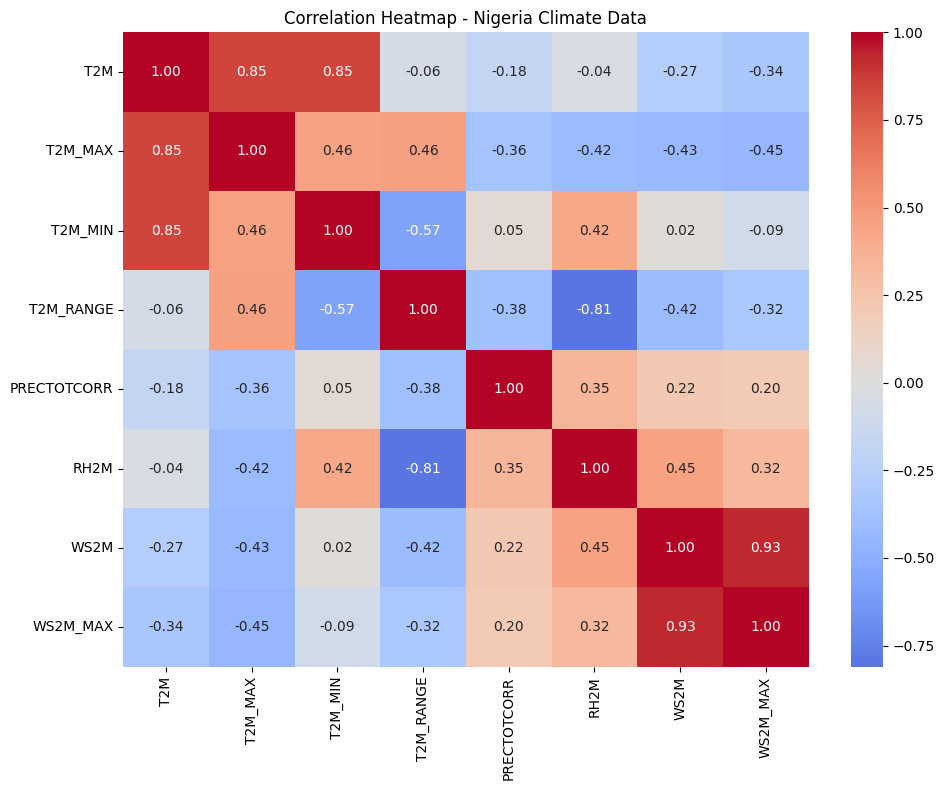

In [9]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Nigeria Climate Data')
plt.tight_layout()
plt.show()

##### Scatter plot: Temperature vs Humidity

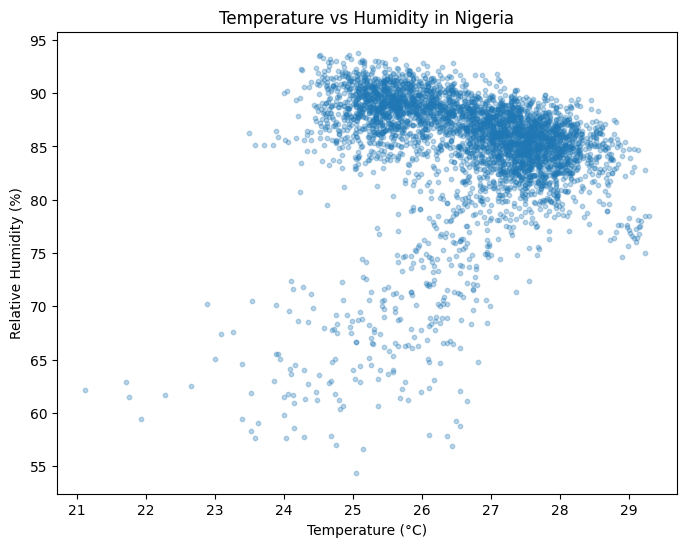

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=10)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Humidity in Nigeria')
plt.show()

##### Scatter plot: Temperature Range vs Wind Speed

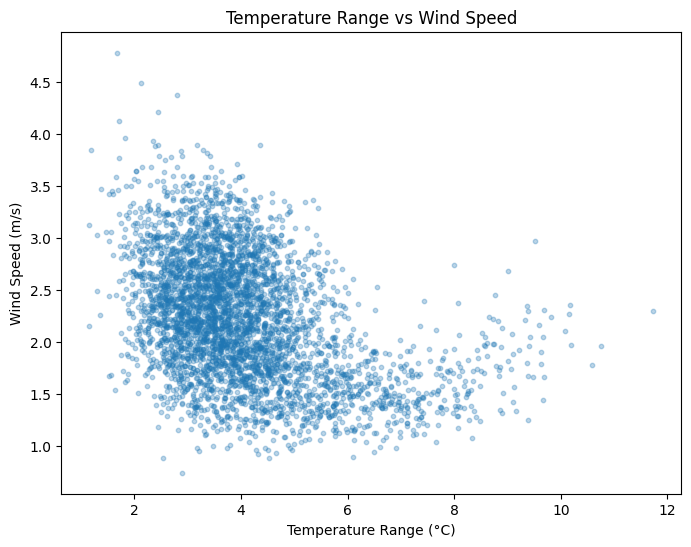

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=10)
plt.xlabel('Temperature Range (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Temperature Range vs Wind Speed')
plt.show()

The three strongest correlations I see are:

1. T2M and T2M_MAX are strongly correlated (0.85). Hotter days have higher average temperatures.
2. T2M_RANGE and T2M_MAX also show correlation.
3. When temperature goes up, some humidity variables show negative relationships.

##### Histogram of rainfall

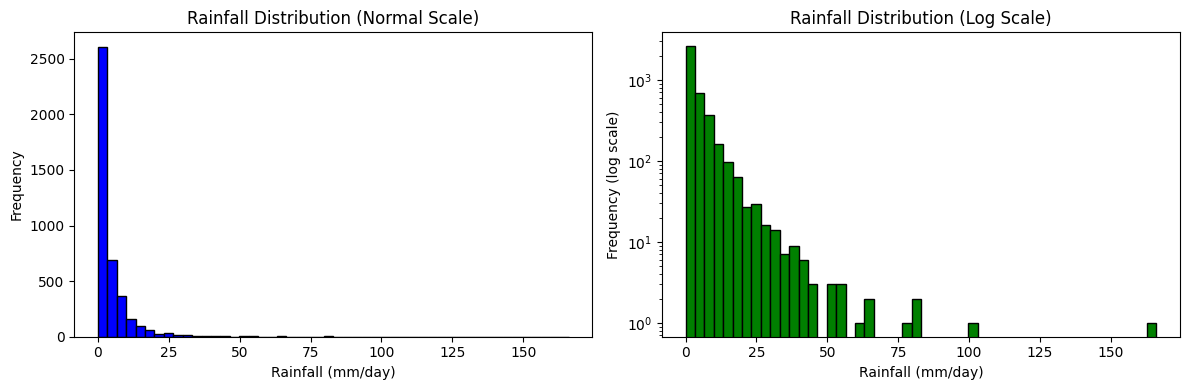

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['PRECTOTCORR'], bins=50, color='blue', edgecolor='black')
axes[0].set_title('Rainfall Distribution (Normal Scale)')
axes[0].set_xlabel('Rainfall (mm/day)')
axes[0].set_ylabel('Frequency')


axes[1].hist(df['PRECTOTCORR'], bins=50, color='green', edgecolor='black', log=True)
axes[1].set_title('Rainfall Distribution (Log Scale)')
axes[1].set_xlabel('Rainfall (mm/day)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

Most days have little or no rain. A few days have a lot of rain up to 150 mm. This is called a skewed distribution. 

##### Bubble chart: Temperature vs Humidity, bubble size = Rainfall

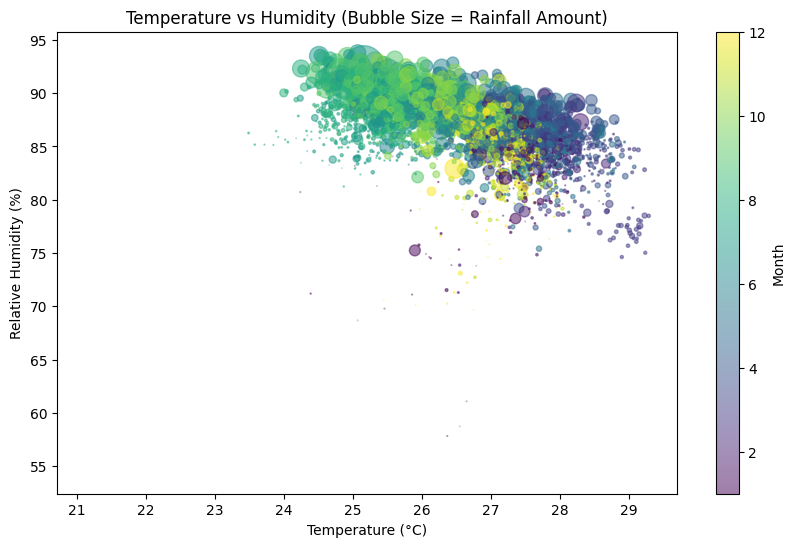

In [13]:

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['T2M'], df['RH2M'], 
                      s=df['PRECTOTCORR'] * 5,  # bubble size = rainfall
                      alpha=0.5, c=df['Month'], cmap='viridis')
plt.colorbar(label='Month')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Humidity (Bubble Size = Rainfall Amount)')
plt.show()

Bigger bubbles (more rain) happen when temperature is cooler. Smaller bubbles (less rain) happen when it's hotter.